#  Uncertainty in Deep Learning
1. Bayesian modeling
2. Bayesian Monte Carlo dropout


## Bayesian modeling

We want to insert some domaine knowledge and put prior on model parameters:
$$
\boldsymbol{\theta} \sim p(\boldsymbol{\theta})
$$

In order to obtain predictive model, one should marginalize $\boldsymbol{\theta}$ using posterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$:
$$
p(y|\mathbf{x}, \mathcal{D}) = \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})p(\boldsymbol{\theta}|\mathcal{D})d\boldsymbol{\theta}
$$

$$
p(\boldsymbol{\theta}|\mathcal{D}) = \frac{p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})}{p(\mathcal{D})}, \quad \text{where } p(\mathcal{D})=\int_{\boldsymbol{\theta}}p(\mathcal{D}|\boldsymbol{\theta})p(\boldsymbol{\theta})d\boldsymbol{\theta}
$$

The measure of the tolal uncertainty is the entropy of predictive disribution $\Eta[y]$, $y\sim p(y|\mathbf{x}, \mathcal{D})$



It is hard to compute porterior distribution $p(\boldsymbol{\theta}|\mathcal{D})$, due to difficulty of evidence computatation $p(\mathcal{D})$.

### Variational inference

We could approximate $p(\boldsymbol{\theta}|\mathcal{D})$ with some distribution $q(\boldsymbol{\theta})$. Then
$$
p(y|\mathbf{x}, \mathcal{D})\approx \int_{\boldsymbol{\theta}}p(y|\mathbf{x}, \boldsymbol{\theta})q(\boldsymbol{\theta})d\boldsymbol{\theta}\approx \frac{1}{M}\sum_{l=1}^M p(y|\mathbf{x}, \boldsymbol{\theta}_l), \quad \boldsymbol{\theta}_l\sim q(\boldsymbol{\theta})
$$

It can be show (see [1]) that neural network trained with dropout approximated posterior $p(\boldsymbol{\theta}|\mathcal{D})$. To get samples from $q(\boldsymbol{\theta})$ we can perform inference with active dropout.

[1] Yarin Gal, Zoubin Ghahramani Proceedings of The 33rd International Conference on Machine Learning, PMLR 48:1050-1059, 2016.
### Uncertainty decomposition

One can distinguish two types of uncertainty: aleatoric and epistemic.

Aleatoric uncertainty is related to inherent ambiguity of the data distribution $p(\mathbf{x}, y)$.

Epistemic uncertainty shows uncertainty in model' paremeters.

Mutial Information (MI) between random variables $y$ and $\boldsymbol{\theta}$ at point $\mathbf{x}$:

$$
\underbrace{MI(y, \boldsymbol{\theta}| \mathcal{D},\mathbf{x})}_{\text{Epistemic uncertainty}} = \underbrace{\Eta_{y\sim p(y|\mathbf{x}, \mathcal{D})}[y]}_{\text{Total uncertainty}} - \underbrace{\mathrm{E}_{p(\boldsymbol{\theta}|\mathcal{D})}\left[\Eta_{y\sim p(y|\mathbf{x}, \boldsymbol{\theta})}[y]\right]}_{\text{Aleatoric uncertainty}}
$$


### Monte Carlo dropout

<Axes: xlabel='x', ylabel='label'>

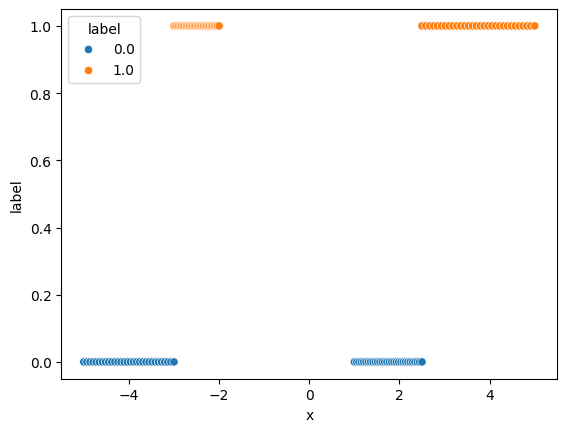

In [4]:
import torch
from torch import nn
import numpy as np
import seaborn as sns
from torch.optim.lr_scheduler import OneCycleLR
import math

# Genetate toy data
end_points = {0: [[-5, -3], [1, 2.5]], 1: [[-3, -2], [2.5, 5]]}
data = []
num_points_per_interval = 30
for class_id, intervals in end_points.items():
    for interval in intervals:
        xs = np.linspace(*interval, num_points_per_interval)
        ys = np.array([class_id] * num_points_per_interval)
        data.append(np.concatenate([xs[:, np.newaxis], ys[:, np.newaxis]], axis=1))
data = np.concatenate(data, axis=0)
data_to_vis = {"x": data[:, 0], "label": data[:, 1]}
sns.scatterplot(data=data_to_vis, x="x", y="label", hue="label")

In [5]:
device = torch.device("cpu")

x = torch.tensor(data[:, 0], dtype=torch.float, device=device)[:, None]

x_norm = (x - torch.min(x)) / (torch.max(x) - torch.min(x))
y = torch.tensor(data[:, 1], dtype=torch.float, device=device)[:, None]


# Use the nn package to define our model and loss function.
dropout_p = 0.2
nn.functional.dropout
model = torch.nn.Sequential(
    torch.nn.Linear(1, 10),
    nn.Sigmoid(),
    torch.nn.Linear(10, 50),
    nn.Dropout(p=dropout_p),
    nn.Sigmoid(),
    torch.nn.Linear(50, 20),
    nn.Sigmoid(),
    torch.nn.Linear(20, 1),
    nn.Flatten(),
    nn.Sigmoid(),
)
model.to(device)

loss_fn = nn.BCELoss()

learning_rate = 1e-2
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

epochs = 4000
scheduler = OneCycleLR(
    optimizer,
    max_lr=1e-1,
    steps_per_epoch=1,
    epochs=epochs,
    div_factor=1e1,
    final_div_factor=1e2,
)
for t in range(epochs):
    # Forward pass: compute predicted y by passing x to the model.
    y_pred = model(x_norm)

    # Compute and print loss.
    loss = loss_fn(y_pred, y)
    if t % 500 == 0:
        print(f"iteration {t}, loss {loss.item()}")
        # print(scheduler.get_lr())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

iteration 0, loss 0.7539355158805847
iteration 500, loss 0.3617272973060608
iteration 1000, loss 0.05291328951716423
iteration 1500, loss 0.11667004972696304
iteration 2000, loss 0.08536543697118759
iteration 2500, loss 0.06459300965070724
iteration 3000, loss 0.04227906093001366
iteration 3500, loss 0.044872984290122986


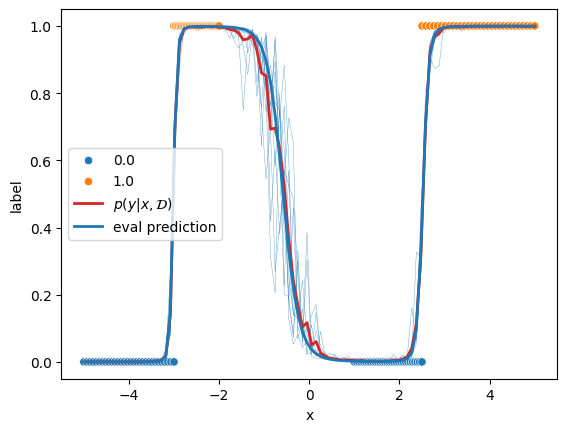

In [6]:
import matplotlib.pyplot as plt

x_test = torch.linspace(-5, 5, 100, device=device)[:, None]
x_test_norm = (x_test - torch.min(x)) / (torch.max(x) - torch.min(x))
num_sample = 10

data_to_vis = {"x": data[:, 0], "label": data[:, 1]}
sns.scatterplot(data=data_to_vis, x="x", y="label", hue="label")

p_preds = []
for _ in range(num_sample):
    model.train()  # we predict in the train mode
    p_pred = model(x_test_norm)[:, 0].detach().cpu().numpy()
    p_preds.append(p_pred[:, None])
    plt.plot(x_test[:, 0].cpu(), p_pred, color="tab:blue", linewidth=0.2)

p_preds = np.concatenate(p_preds, axis=1)
x_test = x_test[:, 0].cpu()
plt.plot(
    x_test,
    np.mean(p_preds, axis=1),
    color="tab:red",
    linewidth=2,
    label=r"$p(y|x, \mathcal{D})$",
)

model.eval()
p_pred_mean = model(x_test_norm)[:, 0].cpu().detach().numpy()
plt.plot(x_test, p_pred_mean, color="tab:blue", linewidth=2, label="eval prediction")
plt.legend()

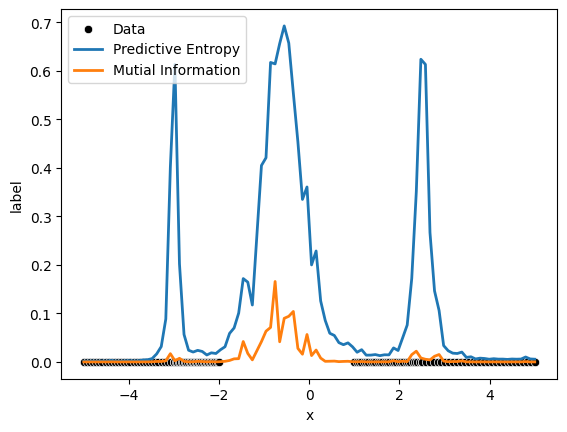

In [8]:
data_to_vis = {"x": data[:, 0], "label": [0] * len(data[:, 0])}
sns.scatterplot(data=data_to_vis, x="x", y="label", color="black", label="Data")

posterior_pred = np.mean(p_preds, axis=1)
predictive_entropy = -(
    posterior_pred * np.log(posterior_pred)
    + (1 - posterior_pred) * np.log(1 - posterior_pred)
)
mutial_information = predictive_entropy - np.mean(
    -(p_preds * np.log(p_preds) + (1 - p_preds) * np.log(1 - p_preds)), axis=1
)
plt.plot(
    x_test,
    predictive_entropy,
    color="tab:blue",
    linewidth=2,
    label="Predictive Entropy",
)
plt.plot(
    x_test,
    mutial_information,
    color="tab:orange",
    linewidth=2,
    label="Mutial Information",
)
plt.legend()